# Conformal Prediction & Calibration : Group Split (by publication)

Train/val/test are split so that no publication bleeds across splits — entire publications are held out of training. Fits KNN, SVR, and NuSVR, then evaluates conformal prediction intervals and per-publication coverage/calibration. Compare against `00_random_split.ipynb`, which splits rows randomly regardless of publication.

In [1]:
import sys
sys.path.insert(0, '../Week-5-6-7-8')

import json
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR, NuSVR

from helpers.modeling import identify_column_types, create_preprocessor
from uncertainty import run_conformal, calibration_table, prepare_data_group,plot_interval_band

with open('../Week-5-6-7-8/results.json', 'r') as f:
    results = json.load(f)

df = pd.read_csv("../Datasets/processed/UHPC_dataset/semantic_recoding_features_50_with_publications.csv")

In [2]:
target_col = 'cs_28d'

# Group-aware split: no publication bleeds across train / val / test
X_train, X_val, X_test, y_train, y_val, y_test = prepare_data_group(
    df, target_col, group_col='paper_reference'
)

pub_train = df.loc[X_train.index, 'paper_reference']
pub_test = df.loc[X_test.index, 'paper_reference']
pub_val  = df.loc[X_val.index,  'paper_reference']

print(f"Train size : {X_train.shape[0]}  ({pub_train.nunique()} publications)")
print(f"Val size   : {X_val.shape[0]}  ({pub_val.nunique()} publications)")
print(f"Test size  : {X_test.shape[0]}  ({pub_test.nunique()} publications)")

numerical_cols, one_hot_columns, k_fold_columns = identify_column_types(X_train)
preprocessor = create_preprocessor(numerical_cols, one_hot_columns, k_fold_columns,
                                   handle_unknown='ignore')
print(f"\nEncoded training shape: {preprocessor.fit_transform(X_train, y_train).shape}")

Train size : 1461  (115 publications)
Val size   : 329  (25 publications)
Test size  : 283  (25 publications)

Encoded training shape: (1461, 69)


In [3]:
pipeline_knn, train_knn, test_knn, q_knn, intervals_knn, calibration_knn = run_conformal(
    KNeighborsRegressor, 'knn', results, 'recoded_50', preprocessor,
    X_train, y_train, X_val, y_val, X_test, y_test, pub_test
)
print(f"Train: {train_knn}")
print(f"Test:  {test_knn}")
print(f"Conformal q (90%): {q_knn:.2f}")
calibration_knn

Train: {'RMSE': np.float64(6.305782110041519), 'MAE': 3.642993552229878, 'MaxAE': 36.013993649028166, 'R2': 0.9630267910608693, 'Correlation': np.float64(0.9815111314284061), 'Mean_Residual': np.float64(-0.15694852534087528), 'N': 1461}
Test:  {'RMSE': np.float64(23.23793904077412), 'MAE': 17.806137524092826, 'MaxAE': 67.02421118381756, 'R2': 0.4009909775827606, 'Correlation': np.float64(0.7324131437056154), 'Mean_Residual': np.float64(-8.05554789148562), 'N': 283}
Conformal q (90%): 74.76


,publication,n_rows,mean_true,mean_prediction,coverage,interval_width,mean_residual,mean_distance
0,Ref-107-Research,16,109.031250,111.465577,1.0,149.510467,7.417548,15.100164
1,Ref-11-Research,4,127.750000,116.633829,1.0,149.510467,11.116171,9.896627
2,Ref-113-Research,5,165.055660,169.659105,1.0,149.510467,7.917274,5.809474
3,Ref-114-Research,5,208.804000,193.074094,1.0,149.510467,16.158349,5.920629
4,Ref-116-Research,36,152.627778,155.914270,1.0,149.510467,5.221121,3.994762
5,Ref-117-Research,5,113.000000,116.284132,1.0,149.510467,13.565680,17.784340
6,Ref-121-Research,80,165.075000,183.741400,1.0,149.510467,23.187495,8.891656
7,Ref-126-Research,5,114.600000,142.713231,1.0,149.510467,28.113231,5.513462
8,Ref-127-Research,3,201.200000,153.290926,1.0,149.510467,47.909074,4.783683
9,Ref-128-Research,3,201.266667,196.900133,1.0,149.510467,4.366533,3.471793


In [4]:
pipeline_svr, train_svr, test_svr, q_svr, intervals_svr, calibration_svr = run_conformal(
    SVR, 'svr', results, 'recoded_50', preprocessor,
    X_train, y_train, X_val, y_val, X_test, y_test, pub_test
)
print(f"Train: {train_svr}")
print(f"Test:  {test_svr}")
print(f"Conformal q (90%): {q_svr:.2f}")
calibration_svr

Train: {'RMSE': np.float64(10.429950222991945), 'MAE': 5.928805099888833, 'MaxAE': 148.93730952147718, 'R2': 0.8988481811434841, 'Correlation': np.float64(0.9481478681514359), 'Mean_Residual': np.float64(-0.3150353833887651), 'N': 1461}
Test:  {'RMSE': np.float64(25.27725398941559), 'MAE': 19.590213058536186, 'MaxAE': 80.18889294508955, 'R2': 0.29124206797394736, 'Correlation': np.float64(0.653952672694027), 'Mean_Residual': np.float64(-5.990714862164412), 'N': 283}
Conformal q (90%): 80.03


,publication,n_rows,mean_true,mean_prediction,coverage,interval_width,mean_residual,mean_distance
0,Ref-107-Research,16,109.031250,126.001997,1.0,160.062911,18.303003,6.605511
1,Ref-11-Research,4,127.750000,114.664598,1.0,160.062911,13.085402,3.668426
2,Ref-113-Research,5,165.055660,166.194438,1.0,160.062911,2.209573,3.134516
3,Ref-114-Research,5,208.804000,179.091486,1.0,160.062911,29.712514,2.208136
4,Ref-116-Research,36,152.627778,148.317312,1.0,160.062911,4.449735,1.931538
5,Ref-117-Research,5,113.000000,127.221299,1.0,160.062911,14.221299,8.217182
6,Ref-121-Research,80,165.075000,173.158337,1.0,160.062911,16.335384,3.889188
7,Ref-126-Research,5,114.600000,161.003013,1.0,160.062911,46.403013,2.477896
8,Ref-127-Research,3,201.200000,152.527104,1.0,160.062911,48.672896,2.086997
9,Ref-128-Research,3,201.266667,207.386256,1.0,160.062911,6.119589,2.164416


In [5]:
pipeline_nusvr, train_nusvr, test_nusvr, q_nusvr, intervals_nusvr, calibration_nusvr = run_conformal(
    NuSVR, 'nusvr', results, 'recoded_50', preprocessor,
    X_train, y_train, X_val, y_val, X_test, y_test, pub_test
)
print(f"Train: {train_nusvr}")
print(f"Test:  {test_nusvr}")
print(f"Conformal q (90%): {q_nusvr:.2f}")
calibration_nusvr

Train: {'RMSE': np.float64(8.942681958482462), 'MAE': 5.784039211218815, 'MaxAE': 51.276468069116845, 'R2': 0.9256390728408297, 'Correlation': np.float64(0.9622759888126655), 'Mean_Residual': np.float64(-0.1464457504855954), 'N': 1461}
Test:  {'RMSE': np.float64(24.854962702891303), 'MAE': 19.191066820679378, 'MaxAE': 75.67361853924251, 'R2': 0.31472580325922006, 'Correlation': np.float64(0.65926922675127), 'Mean_Residual': np.float64(-5.505547900630379), 'N': 283}
Conformal q (90%): 78.86


,publication,n_rows,mean_true,mean_prediction,coverage,interval_width,mean_residual,mean_distance
0,Ref-107-Research,16,109.031250,125.953876,1.0,157.716059,18.155676,6.604402
1,Ref-11-Research,4,127.750000,115.521902,1.0,157.716059,12.228098,3.657978
2,Ref-113-Research,5,165.055660,164.314312,1.0,157.716059,3.075555,3.133515
3,Ref-114-Research,5,208.804000,180.985828,1.0,157.716059,27.818172,2.199948
4,Ref-116-Research,36,152.627778,147.497260,1.0,157.716059,5.178415,1.931497
5,Ref-117-Research,5,113.000000,126.733355,1.0,157.716059,13.733355,8.213795
6,Ref-121-Research,80,165.075000,173.244730,1.0,157.716059,16.560538,3.888415
7,Ref-126-Research,5,114.600000,158.361818,1.0,157.716059,43.761818,2.476701
8,Ref-127-Research,3,201.200000,149.013519,1.0,157.716059,52.186481,2.086763
9,Ref-128-Research,3,201.266667,205.204530,1.0,157.716059,3.937863,2.164416


In [6]:
poor_coverage_threshold = 1

poor_coverage = pd.concat([
    calibration_knn.assign(model='knn'),
    calibration_svr.assign(model='svr'),
    calibration_nusvr.assign(model='nusvr'),
])
poor_coverage = (
    poor_coverage[poor_coverage['coverage'] < poor_coverage_threshold]
    .sort_values('coverage')
    [['model', 'publication', 'n_rows', 'coverage', 'interval_width', 'mean_residual', 'mean_distance']]
    .reset_index(drop=True)
)

print(f"Publications below {poor_coverage_threshold:.0%} coverage: {poor_coverage['publication'].nunique()} unique, {len(poor_coverage)} model-publication pairs")
poor_coverage

Publications below 100% coverage: 1 unique, 1 model-publication pairs


,model,publication,n_rows,coverage,interval_width,mean_residual,mean_distance
0,svr,Ref-93-Research,10,0.9,160.062911,28.305337,3.09544


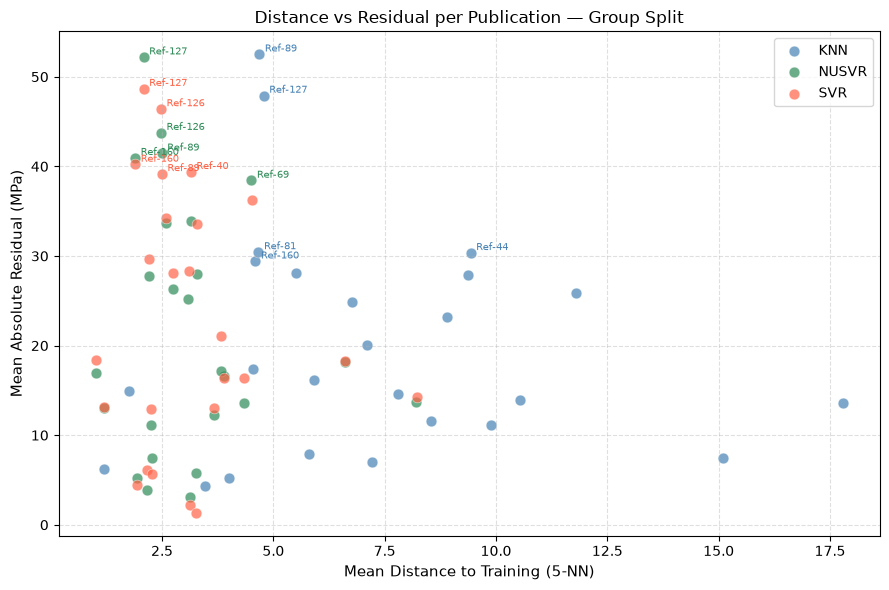

In [7]:
import matplotlib.pyplot as plt

all_cal = pd.concat([
    calibration_knn.assign(model='knn'),
    calibration_svr.assign(model='svr'),
    calibration_nusvr.assign(model='nusvr'),
], ignore_index=True)

colors = {'knn': 'steelblue', 'svr': 'tomato', 'nusvr': 'seagreen'}

fig, ax = plt.subplots(figsize=(9, 6))

for model_name, grp in all_cal.groupby('model'):
    ax.scatter(grp['mean_distance'], grp['mean_residual'],
               label=model_name.upper(), color=colors[model_name],
               alpha=0.7, edgecolors='white', linewidths=0.4, s=60)

# label outliers: top 5 by mean_residual per model
for model_name, grp in all_cal.groupby('model'):
    for _, row in grp.nlargest(5, 'mean_residual').iterrows():
        ax.annotate(row['publication'].replace('-Research', '').replace('-data', ''),
                    xy=(row['mean_distance'], row['mean_residual']),
                    fontsize=7, color=colors[model_name],
                    xytext=(4, 2), textcoords='offset points')

ax.set_xlabel('Mean Distance to Training (5-NN)', fontsize=11)
ax.set_ylabel('Mean Absolute Residual (MPa)', fontsize=11)
ax.set_title('Distance vs Residual per Publication — Group Split', fontsize=12)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [8]:
print(q_knn, q_svr, q_nusvr)

74.75523340103241 80.03145551525697 78.85802939225083


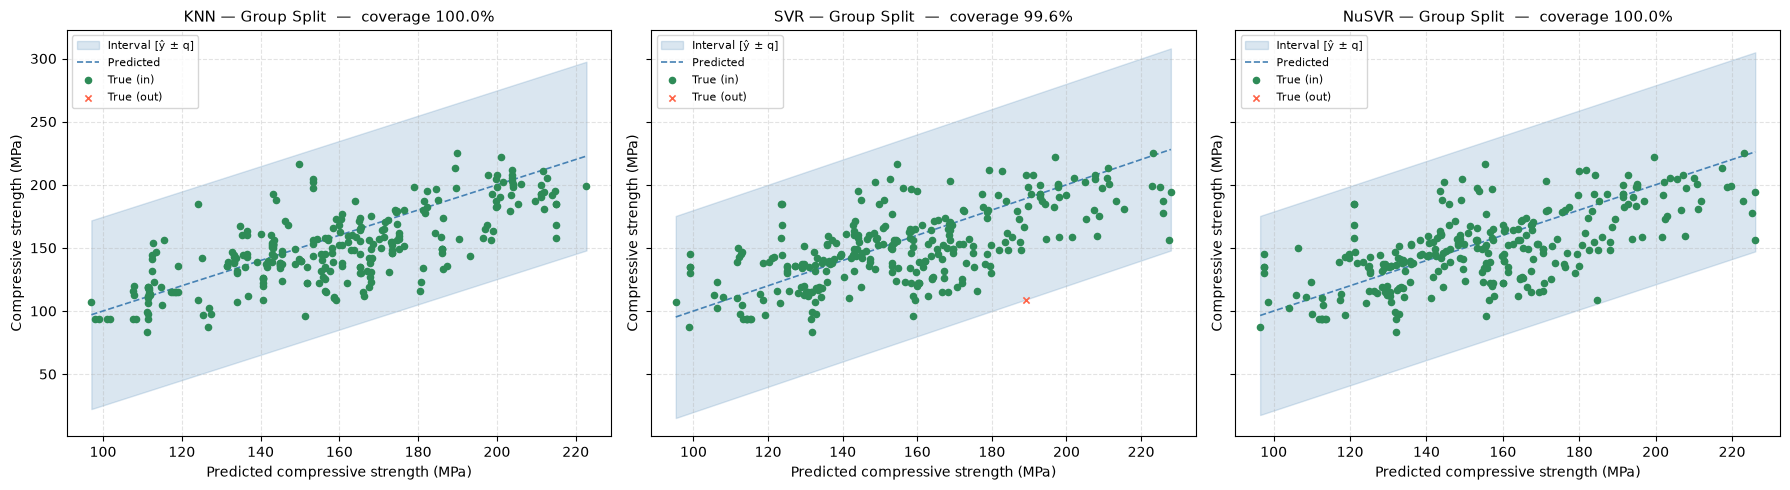

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, ivs, label in zip(
    axes,
    [intervals_knn, intervals_svr, intervals_nusvr],
    ["KNN", "SVR", "NuSVR"],
):
    plot_interval_band(ivs, f"{label} — Group Split", ax=ax)
plt.tight_layout()
plt.show()